## Phase 1: Synthetic Data Generation

In this phase, we generate a reproducible dataset totaling ~8 GB. To simulate a real-world high-throughput scenario, we create individual files ranging from 100 MB to 1 GB.

In [1]:
import os
import torch
import numpy as np
import time
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

#### Configuration & Constants
We define our data bounds and sampling dimensions here. Using a fixed SEED ensures that the benchmark results can be replicated across different environments.

In [2]:
#Making Assumptions for Synthetic Data Generation

OUTPUT_DIR = "data"

TOTAL_SIZE_GB = 8 # Creating around 8 GB of data for benchmarking
MIN_FILE_MB = 100
MAX_FILE_MB = 1000

SAMPLE_DIMENSION = 256 # Each sample will have 256 features/elements

SEED = 100

NUM_WORKERS = [1, 2, 4, 8]

NUM_TRIALS = 5

BATCH_SIZE = 64

MB_TO_BYTES = 1024 * 1024
GB_TO_BYTES = 1024 * MB_TO_BYTES

In [3]:
np.random.seed(SEED)

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [4]:
# Calculate bytes per sample

test_sample = np.random.rand(1, SAMPLE_DIMENSION).astype(np.float32) # 1 sample with 256 features
bytes_per_sample = test_sample.nbytes

print(f"{test_sample.nbytes} bytes")
print(f"Bytes per sample: {bytes_per_sample} bytes")

1024 bytes
Bytes per sample: 1024 bytes


In [5]:
min_num_samples = (MIN_FILE_MB * MB_TO_BYTES) // bytes_per_sample
print(f"Minimum number of samples per file: {min_num_samples}")

Minimum number of samples per file: 102400


In [6]:
max_num_samples = (MAX_FILE_MB * MB_TO_BYTES) // bytes_per_sample
print(f"Maximum number of samples per file: {max_num_samples}")

Maximum number of samples per file: 1024000


In [7]:
total_bytes = TOTAL_SIZE_GB * GB_TO_BYTES
bytes_written = 0
file_count = 1

while bytes_written < total_bytes:
    # Randomly determine file size within our constraints
    num_of_samples = np.random.randint(min_num_samples, max_num_samples + 1)
    data = np.random.rand(num_of_samples, SAMPLE_DIMENSION).astype(np.float32)
    
    file_path = os.path.join(OUTPUT_DIR, f"data_{file_count}.npy")
    
    np.save(file_path, data)
    bytes_written += data.nbytes
    print(f"Written {round(data.nbytes / MB_TO_BYTES, 2)} MB to {file_count} files. Total bytes written: {round(bytes_written / GB_TO_BYTES, 2)} GB")
    file_count += 1

    
print("Dataset Successfully Generated.")

Written 578.73 MB to 1 files. Total bytes written: 0.57 GB
Written 142.39 MB to 2 files. Total bytes written: 0.7 GB
Written 681.02 MB to 3 files. Total bytes written: 1.37 GB
Written 443.65 MB to 4 files. Total bytes written: 1.8 GB
Written 211.0 MB to 5 files. Total bytes written: 2.01 GB
Written 877.19 MB to 6 files. Total bytes written: 2.87 GB
Written 170.58 MB to 7 files. Total bytes written: 3.03 GB
Written 122.39 MB to 8 files. Total bytes written: 3.15 GB
Written 141.05 MB to 9 files. Total bytes written: 3.29 GB
Written 752.38 MB to 10 files. Total bytes written: 4.02 GB
Written 532.58 MB to 11 files. Total bytes written: 4.54 GB
Written 661.77 MB to 12 files. Total bytes written: 5.19 GB
Written 488.39 MB to 13 files. Total bytes written: 5.67 GB
Written 219.02 MB to 14 files. Total bytes written: 5.88 GB
Written 204.65 MB to 15 files. Total bytes written: 6.08 GB
Written 250.5 MB to 16 files. Total bytes written: 6.33 GB
Written 409.17 MB to 17 files. Total bytes written: 6

In [8]:
# Actual Size on Disk

total_size_on_disk = sum(os.path.getsize(os.path.join(OUTPUT_DIR, f)) for f in os.listdir(OUTPUT_DIR))
print(f"Total size on disk: {round(total_size_on_disk / (GB_TO_BYTES), 2)} GB")

Total size on disk: 8.22 GB


## Phase 2: Implementation

- We treat multiple separate files on disk as one continuous array.
- Data is only read from disk when __getitem__ is called.

In [9]:
class SyntheticDataset(Dataset):
    def __init__(self, data_dir):

        self.data_dir = data_dir

        self.data_files = sorted([os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith('.npy')])

        self.data_chunks = [np.load(f, mmap_mode='r') for f in self.data_files]
        self.samples_per_chunk = [chunk.shape[0] for chunk in self.data_chunks]
        self.cumulative_sizes = np.cumsum(self.samples_per_chunk)

        self.total_samples = self.cumulative_sizes[-1] if self.cumulative_sizes.size > 0 else 0
        self.feature_dim = self.data_chunks[0].shape[1] if self.data_chunks else 0
        
        
    
    def __len__(self):
        return self.total_samples
    
    def __getitem__(self, idx):
        if idx < 0 or idx >= self.total_samples:
            raise IndexError("Index out of range")
        
        chunk_idx = np.searchsorted(self.cumulative_sizes, idx, side='right')
        
        if chunk_idx == 0:
            sample_idx = idx
        else:
            sample_idx = idx - self.cumulative_sizes[chunk_idx - 1]

        sample = self.data_chunks[chunk_idx][sample_idx]
        return torch.from_numpy(sample.copy())

In [10]:
# Quick Sanity Check
dataset = SyntheticDataset(OUTPUT_DIR)
print(f"Total samples in dataset: {len(dataset)}")
print(f"Feature dimension: {dataset.feature_dim}")

try:
    last_sample = dataset[len(dataset)-1]
    print(f"Indexing Check Passed (Last Sample: {last_sample.shape})")
except IndexError:
    print("Indexing Check Failed!")

Total samples in dataset: 8623686
Feature dimension: 256
Indexing Check Passed (Last Sample: torch.Size([256]))


## Phase 3: Benchmarking

In [11]:
def run_benchmark(num_workers, dataset, batch_size=BATCH_SIZE):
    dataloader = DataLoader(dataset, batch_size=batch_size, num_workers=num_workers)
    start_time = time.perf_counter()

    for batch in dataloader:
        pass

    end_time = time.perf_counter()

    total_time = end_time - start_time
    throughput = len(dataset) / total_time

    return total_time, throughput

In [12]:
experiment_results = {}

for num_workers in NUM_WORKERS:
    print(f"Running benchmark with {num_workers} workers...")

    time_taken, throughput = run_benchmark(num_workers, dataset)
    experiment_results[num_workers] = {"time_taken": time_taken, "throughput": throughput}

    print(f"Total iteration time with {num_workers} workers: {round(time_taken, 2)} seconds")
    print(f"Throughput with {num_workers} workers: {round(throughput, 2)} samples/second")
    print("-" * 50)
    

Running benchmark with 1 workers...
Total iteration time with 1 workers: 65.05 seconds
Throughput with 1 workers: 132564.38 samples/second
--------------------------------------------------
Running benchmark with 2 workers...
Total iteration time with 2 workers: 34.04 seconds
Throughput with 2 workers: 253308.19 samples/second
--------------------------------------------------
Running benchmark with 4 workers...
Total iteration time with 4 workers: 26.71 seconds
Throughput with 4 workers: 322901.06 samples/second
--------------------------------------------------
Running benchmark with 8 workers...
Total iteration time with 8 workers: 28.28 seconds
Throughput with 8 workers: 304948.61 samples/second
--------------------------------------------------


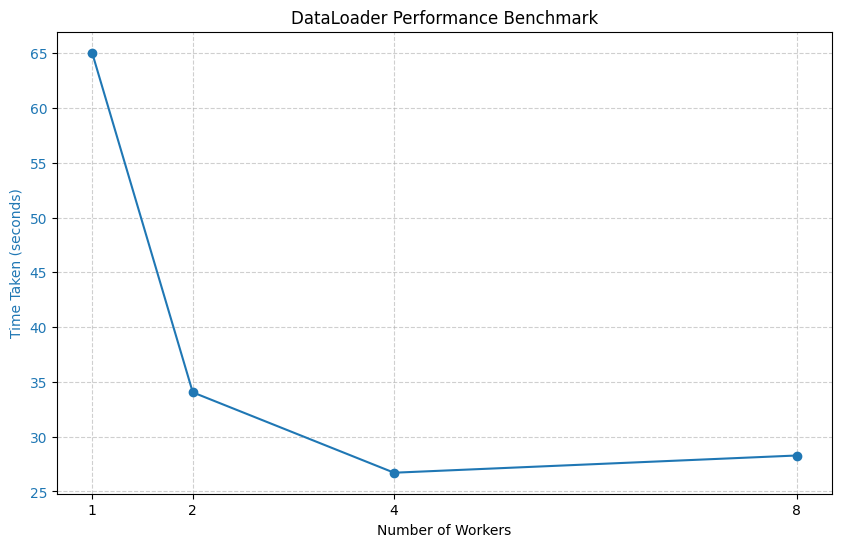

In [13]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Number of Workers')
ax1.set_ylabel('Time Taken (seconds)', color=color)
ax1.plot(NUM_WORKERS, [res['time_taken'] for res in experiment_results.values()], marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)    
ax1.grid(True, linestyle='--', alpha=0.6)

plt.title('DataLoader Performance Benchmark')
plt.xticks(NUM_WORKERS)
plt.show()

In [14]:
# Observable Scaling Efficiency

efficiency_results = {}

T1 = experiment_results[1]['time_taken']
for num_workers, results in experiment_results.items():
    time_taken = results['time_taken']
    efficiency = (T1 / time_taken) / num_workers * 100
    efficiency_results[num_workers] = efficiency
    print(f"Scaling efficiency with {num_workers} workers: {round(efficiency, 2)}%")
    print("-" * 50)

Scaling efficiency with 1 workers: 100.0%
--------------------------------------------------
Scaling efficiency with 2 workers: 95.54%
--------------------------------------------------
Scaling efficiency with 4 workers: 60.9%
--------------------------------------------------
Scaling efficiency with 8 workers: 28.75%
--------------------------------------------------


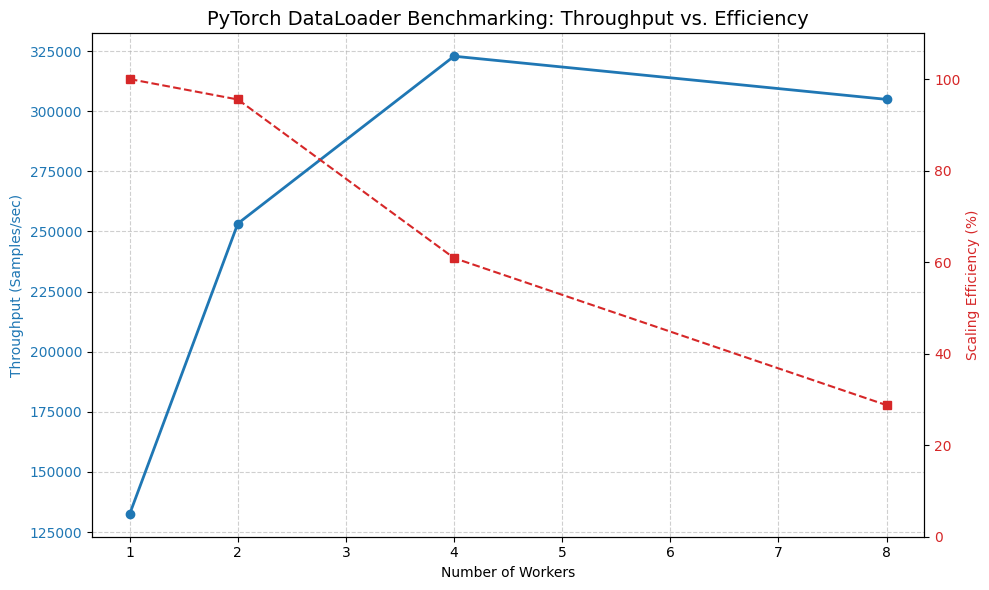

In [15]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Number of Workers')
ax1.set_ylabel('Throughput (Samples/sec)', color=color)
ax1.plot(NUM_WORKERS, [results['throughput'] for _, results in experiment_results.items()], marker='o', linewidth=2, color=color, label='Throughput')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.6)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Scaling Efficiency (%)', color=color)
ax2.plot(NUM_WORKERS, [efficiency for _, efficiency in efficiency_results.items()], marker='s', linestyle='--', color=color, label='Efficiency')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 110)

plt.title('PyTorch DataLoader Benchmarking: Throughput vs. Efficiency', fontsize=14)
fig.tight_layout()
plt.show()

### Adding Statistical Robustness

Individual benchmark runs can vary based on system state. To ensure the validity of our results, we executed 5 trials per configuration:

- Mean Time: Represents the expected performance.
- Standard Deviation ($\sigma$): Indicates the "noise" or consistency. A high $\sigma$ suggests that background processes or I/O spikes interfered with the test.

In [16]:
trial_based_experiment_results = {}

for num_workers in NUM_WORKERS:
    trial_times = []
    throughput_values = []

    for trial in range(NUM_TRIALS):
        print(f"Trial {trial + 1}/{NUM_TRIALS} with {num_workers} workers...")

        time_taken, throughput = run_benchmark(num_workers, dataset)
        trial_times.append(time_taken)
        throughput_values.append(throughput)

        print(f"Time taken for trial {trial + 1}: {round(time_taken, 2)} seconds")
        print(f"Throughput for trial {trial + 1}: {round(throughput, 2)} samples/second")

    avg_time = np.mean(trial_times)
    avg_throughput = np.mean(throughput_values)
    std_time = np.std(trial_times)

    print(f"Average time taken with {num_workers} workers over {NUM_TRIALS} trials: {round(avg_time, 2)} seconds")
    print(f"Average throughput with {num_workers} workers over {NUM_TRIALS} trials: {round(avg_throughput, 2)} samples/second")
    print(f"Standard deviation of time with {num_workers} workers over {NUM_TRIALS} trials: {round(std_time, 2)} seconds")
    print("-" * 50)
    trial_based_experiment_results[num_workers] = {
        "average_time": avg_time,
        "average_throughput": avg_throughput,
        "std_time": std_time
    }

Trial 1/5 with 1 workers...
Time taken for trial 1: 51.5 seconds
Throughput for trial 1: 167443.54 samples/second
Trial 2/5 with 1 workers...
Time taken for trial 2: 51.93 seconds
Throughput for trial 2: 166064.08 samples/second
Trial 3/5 with 1 workers...
Time taken for trial 3: 53.55 seconds
Throughput for trial 3: 161050.85 samples/second
Trial 4/5 with 1 workers...
Time taken for trial 4: 52.1 seconds
Throughput for trial 4: 165510.55 samples/second
Trial 5/5 with 1 workers...
Time taken for trial 5: 52.46 seconds
Throughput for trial 5: 164377.36 samples/second
Average time taken with 1 workers over 5 trials: 52.31 seconds
Average throughput with 1 workers over 5 trials: 164889.28 samples/second
Standard deviation of time with 1 workers over 5 trials: 0.69 seconds
--------------------------------------------------
Trial 1/5 with 2 workers...
Time taken for trial 1: 34.66 seconds
Throughput for trial 1: 248783.15 samples/second
Trial 2/5 with 2 workers...
Time taken for trial 2: 34

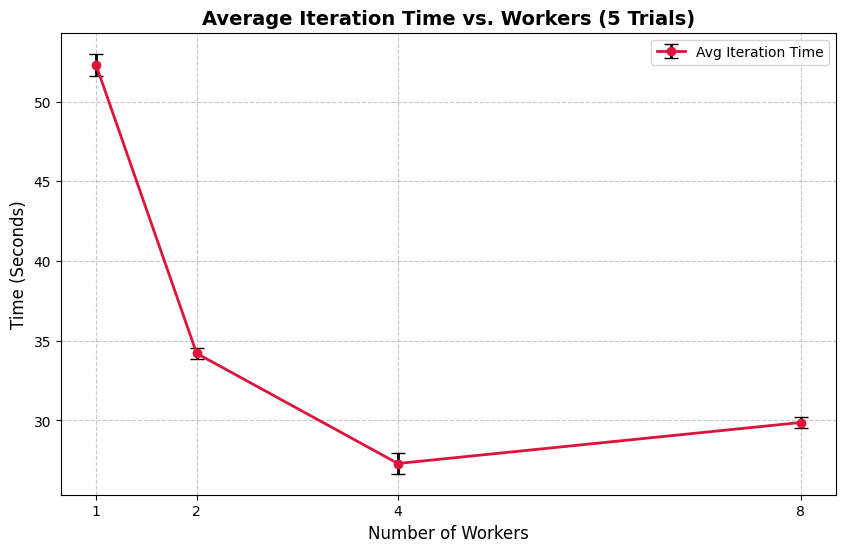

In [17]:
plt.figure(figsize=(10, 6))
plt.errorbar(NUM_WORKERS, [trial_based_experiment_results[worker]['average_time'] for worker in NUM_WORKERS], yerr=[trial_based_experiment_results[worker]['std_time'] for worker in NUM_WORKERS], fmt='-o', color='crimson', 
             ecolor='black', capsize=5, elinewidth=2, linewidth=2, label='Avg Iteration Time')

plt.xlabel('Number of Workers', fontsize=12)
plt.ylabel('Time (Seconds)', fontsize=12)
plt.title('Average Iteration Time vs. Workers (5 Trials)', fontsize=14, fontweight='bold')
plt.xticks(NUM_WORKERS)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

In [18]:
trial_based_efficiency_results = {}
trial_based_T1 = trial_based_experiment_results[1]['average_time']
for num_workers, results in trial_based_experiment_results.items():
    avg_time = results['average_time']
    efficiency = (trial_based_T1 / avg_time) / num_workers * 100
    trial_based_efficiency_results[num_workers] = efficiency
    print(f"Trial-based scaling efficiency with {num_workers} workers: {round(efficiency, 2)}%")
    print("-" * 50)

Trial-based scaling efficiency with 1 workers: 100.0%
--------------------------------------------------
Trial-based scaling efficiency with 2 workers: 76.46%
--------------------------------------------------
Trial-based scaling efficiency with 4 workers: 47.91%
--------------------------------------------------
Trial-based scaling efficiency with 8 workers: 21.89%
--------------------------------------------------


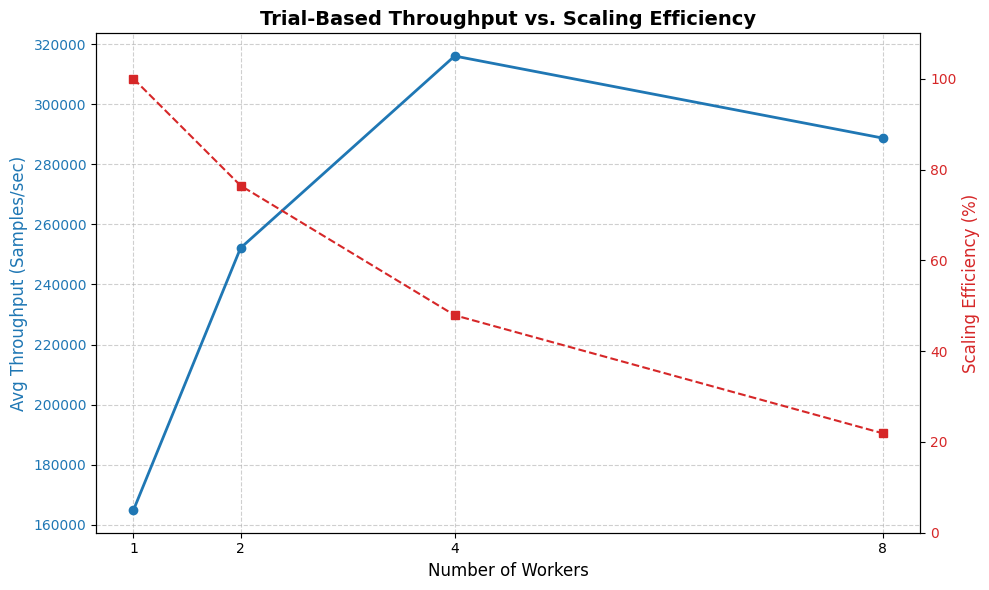

In [19]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Number of Workers', fontsize=12)
ax1.set_ylabel('Avg Throughput (Samples/sec)', color=color, fontsize=12)
ax1.plot(NUM_WORKERS, [trial_based_experiment_results[worker]['average_throughput'] for worker in NUM_WORKERS], marker='o', linewidth=2, color=color, label='Throughput')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.6)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Scaling Efficiency (%)', color=color, fontsize=12)
ax2.plot(NUM_WORKERS, [trial_based_efficiency_results[worker] for worker in NUM_WORKERS], marker='s', linestyle='--', color=color, label='Efficiency')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 110)

plt.title('Trial-Based Throughput vs. Scaling Efficiency', fontsize=14, fontweight='bold')
plt.xticks(NUM_WORKERS)
fig.tight_layout()
plt.show()